In [1]:
#| echo: false

from IPython.display import Image, display, HTML

# Create HTML layout for side-by-side images
html_content = """
<div style="display: flex; gap: 20px;">
    <img src="https://pandas.pydata.org/docs/_images/merging_join_multi_df.png" width="650" />
</div>
"""

# Display the images side by side
display(HTML(html_content))

## Introduction: Why Combine Datasets?

In real-world data analysis, information is rarely contained in a single dataset. You'll often need to **combine multiple datasets** from different sources to get a complete picture. This process is fundamental to data analysis and goes by several names:

- **Merging** - joining datasets based on common keys
- **Joining** - combining datasets using indices
- **Concatenating** - stacking datasets vertically or horizontally

### Common Scenarios Requiring Data Combination

**1. Distributed Information**

- Customer demographics in one table, purchase history in another
- Product details separate from sales transactions
- Survey responses split across multiple files

**2. Data from Multiple Sources**

- Internal company data + external market data
- Multiple databases (HR, Sales, Inventory)
- Different time periods stored in separate files

**3. Analytical Requirements**

- Enriching existing data with additional attributes
- Comparing data across different groups or time periods
- Building comprehensive datasets for machine learning

### The Three Main Combination Methods

Pandas provides three powerful functions for combining datasets, each suited to different scenarios:

| Method | Function | Use Case | Key Parameter |
|--------|----------|----------|---------------|
| **Merge** | `merge()` | Combine datasets with common columns (like SQL JOIN) | `on=` (column name) |
| **Join** | `join()` | Combine datasets using their indices | `lsuffix=`, `rsuffix=` |
| **Concatenate** | `concat()` | Stack datasets vertically or horizontally | `axis=` (0 or 1) |

In this chapter, we'll explore each method with practical examples, understand when to use which approach, and learn how to handle common challenges like missing values and duplicate columns.

### Setup: Loading Required Libraries

Let's start by importing the necessary libraries and loading our example datasets.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for better output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## Method 1: Merging with `merge()`

The `merge()` function is pandas' most versatile tool for combining datasets. It works similarly to **SQL JOIN operations**, combining DataFrames based on one or more **common columns** (called keys).


### Basic Syntax

```python
pd.merge(left_df, right_df, on='key_column', how='inner')
```

Or using the DataFrame method:

```python
left_df.merge(right_df, on='key_column', how='inner')
```

Let's see this in action!

### Example Datasets: Lord of the Rings Fellowship

Throughout this chapter, we'll use multiple datasets that contain complementary information, we'll combine using different methods.

Let's first load the **primary dataset** containing basic fellowship member information:

In [4]:
# Load the primary dataset
df_existing = pd.read_csv('./datasets/LOTR.csv')

print(f"Dataset shape: {df_existing.shape}")
print(f"Columns: {list(df_existing.columns)}\n")

df_existing.head()

Dataset shape: (4, 3)
Columns: ['FellowshipID', 'FirstName', 'Skills']



,FellowshipID,FirstName,Skills
0,1001,Frodo,Hiding
1,1002,Samwise,Gardening
2,1003,Gandalf,Spells
3,1004,Pippin,Fireworks


Now let's load the **external dataset** containing additional information about the fellowship members:

In [5]:
# Load the external dataset
df_external = pd.read_csv("./datasets/LOTR 2.csv")

print(f"Dataset shape: {df_external.shape}")
print(f"Columns: {list(df_external.columns)}\n")

df_external.head()

Dataset shape: (5, 3)
Columns: ['FellowshipID', 'FirstName', 'Age']



,FellowshipID,FirstName,Age
0,1001,Frodo,50
1,1002,Samwise,39
2,1006,Legolas,2931
3,1007,Elrond,6520
4,1008,Barromir,51


**Observation:** Both datasets contain information about fellowship members, but they may have:

- **Common columns** that can serve as keys for merging (like `FellowshipID` or `Name`)
- **Different sets of attributes** that complement each other
- **Potentially different numbers of rows** (not all members may appear in both datasets)

Our goal is to combine these datasets to create a comprehensive view of the fellowship.

### Example 1: Basic Merge with Automatic Key Detection

When both DataFrames have columns with the same name, `merge()` automatically uses them as keys:

In [6]:
# Merge using automatic key detection
df_merged = pd.merge(df_existing, df_external)

print(f"Original datasets: {df_existing.shape} + {df_external.shape}")
print(f"Merged dataset: {df_merged.shape}")
print(f"\nMerged columns: {list(df_merged.columns)}\n")

df_merged.head()

Original datasets: (4, 3) + (5, 3)
Merged dataset: (2, 4)

Merged columns: ['FellowshipID', 'FirstName', 'Skills', 'Age']



,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


**Alternative Syntax:** You can also use the DataFrame method, which is more readable in method chains:

In [7]:
# Using DataFrame.merge() method (equivalent to above)
df_merged_method = df_existing.merge(df_external)

print(f"Results are identical: {df_merged.equals(df_merged_method)}")
print(f"Merged dataset shape: {df_merged_method.shape}\n")

df_merged_method.head()

Results are identical: True
Merged dataset shape: (2, 4)



,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


### Example 2: Merging with Different Column Names

What if the key columns have **different names** in each DataFrame? Use the `left_on` and `right_on` parameters to specify which columns to match.

In [ ]:
# Example: Suppose the external dataset uses 'ID' instead of 'FellowshipID'
# Let's create a version with a different column name to demonstrate
df_external_renamed = df_external.rename(columns={'FellowshipID': 'ID'})

print("External dataset columns after renaming:")
print(list(df_external_renamed.columns))
print()

# Now merge using left_on and right_on
df_merged_diff = pd.merge(
    df_existing, 
    df_external_renamed,
    left_on='FellowshipID',   # Column name in left DataFrame
    right_on='ID'              # Column name in right DataFrame
)

print(f"Merged dataset shape: {df_merged_diff.shape}")
print(f"Merged columns: {list(df_merged_diff.columns)}\n")

df_merged_diff.head()

**Important observations:**

- Notice that **both** key columns (`FellowshipID` and `ID`) appear in the result
- They contain identical values (the matched keys)
- You can drop one of them after merging: `df_merged_diff.drop('ID', axis=1)`

**Common use case:** Merging data from different sources where column naming conventions differ (e.g., `customer_id` vs `cust_id`, `date` vs `timestamp`).

### Example 3: Merging on Multiple Columns

Sometimes you need to match rows based on **multiple columns** together (composite keys). This is common when a single column isn't unique.

In [ ]:
# Example: Merge on both Name AND Race to ensure exact matches
df_multi_key = pd.merge(
    df_existing, 
    df_external,
    on=['Name', 'Race']  # Both columns must match
)

print(f"Merged on multiple keys: {df_multi_key.shape}")
print("\nMerging on multiple columns ensures rows match on ALL specified keys\n")

df_multi_key.head()

**Real-world examples of composite keys:**

- **Sales transactions:** Match on both `Store_ID` AND `Date` (same store can have sales on different dates)
- **Student grades:** Match on `Student_ID` AND `Course_ID` (same student takes multiple courses)
- **Time series data:** Match on `Location` AND `Timestamp` (multiple locations measured over time)

**Syntax variations:**
```python
# Using on= (when column names are the same)
pd.merge(df1, df2, on=['col1', 'col2'])

# Using left_on= and right_on= (when column names differ)
pd.merge(df1, df2, left_on=['id', 'date'], right_on=['ID', 'timestamp'])
```

### Understanding Join Types: The `how` Parameter

By default, `merge()` performs an **inner join**, which keeps only rows where the key exists in **both** DataFrames. However, you can control this behavior using the `how` parameter.

**The Four Join Types:**

| Join Type | `how=` | Keeps Rows From | Use Case |
|-----------|--------|-----------------|----------|
| **Inner** | `'inner'` | Both (intersection) | Only matching records |
| **Left** | `'left'` | All from left + matches from right | Keep all primary data |
| **Right** | `'right'` | All from right + matches from left | Keep all secondary data |
| **Outer** | `'outer'` | Both (union) | Keep everything |

<div style="text-align: center;">
<img src="https://miro.medium.com/v2/resize:fit:752/0*ZGDgg-0SznYlwiij.png" alt="Join Types Visualization" width="500px">
</div>

Let's explore each type with examples.

#### Inner Join (Default): Only Matching Rows

An **inner join** returns only the rows where the key exists in both DataFrames. This is the default behavior.

In [8]:
# Inner join - explicitly specified (same as default)
df_inner = pd.merge(df_existing, df_external, how='inner')

print(f"Inner join result: {df_inner.shape}")
print("Only rows with matching keys in BOTH datasets are kept\n")

df_inner.head()

Inner join result: (2, 4)
Only rows with matching keys in BOTH datasets are kept



,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


**When to use inner join:**

Use inner join when you need **complete information** from both datasets for your analysis.

**Real-world examples:**

1. **Analyzing vaccination impact on COVID infection rates**
   
   - Dataset 1: COVID infection rates by country
   - Dataset 2: Vaccination counts by country
   - **Why inner join?** You can't analyze the relationship unless you have BOTH metrics for a country. Countries missing either value can't contribute to the analysis.

2. **Customer purchase analysis**
   
   - Dataset 1: Customer demographics
   - Dataset 2: Purchase transactions
   - **Why inner join?** To analyze how demographics relate to purchases, you need both demographic info AND purchase history.

3. **A/B testing results**
   
   - Dataset 1: User group assignments (control/treatment)
   - Dataset 2: Conversion outcomes
   - **Why inner join?** Only users with both group assignment AND outcome data can be included in the test analysis.

#### Left Join: Keep All Left DataFrame Rows

A **left join** returns **all rows from the left DataFrame** and matching rows from the right DataFrame. Non-matching rows from the right will have `NaN` values.



In [9]:
# Left join - keep all rows from left (existing) dataset
df_left = pd.merge(df_existing, df_external, how='left')

print(f"Left DataFrame shape: {df_existing.shape}")
print(f"Right DataFrame shape: {df_external.shape}")
print(f"Left join result: {df_left.shape}")
print("\nAll rows from LEFT dataset are kept, even if no match in RIGHT\n")

# Show rows with missing values from the right dataset
missing_count = df_left.isnull().any(axis=1).sum()
print(f"Rows with NaN values (no match in right dataset): {missing_count}\n")

df_left.head(10)

Left DataFrame shape: (4, 3)
Right DataFrame shape: (5, 3)
Left join result: (4, 4)

All rows from LEFT dataset are kept, even if no match in RIGHT

Rows with NaN values (no match in right dataset): 2



,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50.0
1,1002,Samwise,Gardening,39.0
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN


**When to use left join:**

Use left join when the **left dataset contains your primary data** that must be retained, while the right dataset provides supplementary information that may be missing for some records.

**Real-world examples:**

1. **COVID infection rates + government effectiveness scores**
   
   - Left: COVID infection rates (critical, hard to impute)
   - Right: Government effectiveness scores (can be estimated from GDP, crime rate, etc.)
   - **Why left join?** Keep all countries with infection rate data. Missing government scores can be imputed later using correlated variables.

2. **Customer demographics + credit card spending**
   
   - Left: Customer demographics (all customers)
   - Right: Credit card transactions (only customers who made purchases)
   - **Why left join?** Keep all customers, even those with no purchases. Missing spend can be filled with 0 (indicating no transactions).

3. **Employee records + performance reviews**
   
   - Left: All employee records
   - Right: Recent performance reviews (not all employees reviewed yet)
   - **Why left join?** Maintain complete employee roster. Missing reviews can be handled separately (e.g., "Pending" status).

**Key principle:** Use left join when you can't afford to lose the left dataset's records, and missing right-side values can be reasonably handled (imputed, filled with defaults, or marked as missing).

#### Right Join: Keep All Right DataFrame Rows

A **right join** is the mirror image of a left join—it returns **all rows from the right DataFrame** and matching rows from the left DataFrame.

In [10]:
# Right join - keep all rows from right (external) dataset  
df_right = pd.merge(df_existing, df_external, how='right')

print(f"Left DataFrame shape: {df_existing.shape}")
print(f"Right DataFrame shape: {df_external.shape}")
print(f"Right join result: {df_right.shape}")
print("\nAll rows from RIGHT dataset are kept, even if no match in LEFT\n")

df_right.head()

Left DataFrame shape: (4, 3)
Right DataFrame shape: (5, 3)
Right join result: (5, 4)

All rows from RIGHT dataset are kept, even if no match in LEFT



,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39
2,1006,Legolas,NaN,2931
3,1007,Elrond,NaN,6520
4,1008,Barromir,NaN,51


**When to use right join:**

Right join serves the same purpose as left join, just with the DataFrames swapped. In practice:

- **Most analysts prefer left join** because it's more intuitive (reads left-to-right)
- **Right join is rarely used** - you can always swap the DataFrames and use left join instead

**Example equivalence:**
```python
# These produce the same result:
df_right = pd.merge(df_A, df_B, how='right')  # Right join
df_left = pd.merge(df_B, df_A, how='left')    # Equivalent left join
```

**When you might see right join:**

- Legacy code or specific coding style preferences
- SQL background where RIGHT JOIN might be more familiar
- Method chaining where the order is determined by workflow

**Best practice:** Stick with left join and arrange your DataFrames accordingly—it makes code more readable and maintainable.

#### Outer Join: Keep All Rows from Both DataFrames

An **outer join** (also called a **full outer join**) returns **all rows from both DataFrames**, with `NaN` values where matches don't exist. This is the most inclusive join type—no data is lost.

In [11]:
# Outer join - keep all rows from BOTH datasets
df_outer = pd.merge(df_existing, df_external, how='outer')

print(f"Left DataFrame shape: {df_existing.shape}")
print(f"Right DataFrame shape: {df_external.shape}")
print(f"Outer join result: {df_outer.shape}")
print("\nAll rows from BOTH datasets are kept, with NaN for non-matches\n")

# Check for missing values
print("Missing values per column:")
print(df_outer.isnull().sum())
print()

df_outer

Left DataFrame shape: (4, 3)
Right DataFrame shape: (5, 3)
Outer join result: (7, 4)

All rows from BOTH datasets are kept, with NaN for non-matches

Missing values per column:
FellowshipID    0
FirstName       0
Skills          3
Age             2
dtype: int64



,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50.0
1,1002,Samwise,Gardening,39.0
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN
4,1006,Legolas,NaN,2931.0
5,1007,Elrond,NaN,6520.0
6,1008,Barromir,NaN,51.0


**When to use outer join:**

Use outer join when you **cannot afford to lose any data** from either dataset, even if it means having incomplete records.

**Real-world examples:**

1. **Course surveys from multiple time points**
   
   - Dataset 1: Mid-semester survey responses
   - Dataset 2: End-of-semester survey responses
   - **Why outer join?** Students who responded to either survey provide valuable feedback. Keep all responses, even from students who only completed one survey. Analyze response patterns and sentiment across all participants.

2. **Multi-source customer data integration**
   
   - Dataset 1: Online purchase records
   - Dataset 2: In-store purchase records
   - **Why outer join?** Customers may shop through one channel only. Keep all customers to understand total customer base and channel preferences.

3. **Scientific study with partial data**
   
   - Dataset 1: Lab test results
   - Dataset 2: Clinical observations
   - **Why outer join?** Some subjects may have only lab results or only clinical observations due to scheduling, dropouts, or data collection issues. Keep all subjects to maximize sample size and identify patterns in data availability.

4. **Data quality auditing**
   
   - Dataset 1: Expected records (should exist)
   - Dataset 2: Actual records (what we have)
   - **Why outer join?** Identify both missing expected records (in left but not right) and unexpected extra records (in right but not left) for data quality assessment.

**Key principle:** Use outer join when completeness trumps having matched pairs, and you'll handle missing values appropriately in subsequent analysis.

## Method 2: Joining with `join()`

While `merge()` combines DataFrames based on **column values**, the `join()` method combines them based on their **indices**. This is particularly useful when your DataFrames are already indexed by a meaningful key (like customer ID, timestamp, etc.).


### Key Difference: `merge()` vs `join()`

| Aspect | `merge()` | `join()` |
|--------|-----------|----------|
| **Joins on** | Column values | Index values |
| **Default join** | Inner | Left |
| **Syntax** | More explicit | More concise |
| **Use when** | Keys are in columns | Keys are in index |

### Important: Handling Overlapping Columns

Unlike `merge()`, `join()` requires you to specify **suffixes** for overlapping column names (it has no default). This is done with the `lsuffix` and `rsuffix` parameters.

Let's see what happens without suffixes:

The code above will raise an error because both DataFrames have overlapping column names, and `join()` doesn't know how to handle them without suffixes.

**Let's fix this by adding suffixes:**

In [12]:
# Join with suffixes to handle overlapping column names
df_joined = df_existing.join(
    df_external, 
    lsuffix='_existing',  # Suffix for left DataFrame columns
    rsuffix='_external'    # Suffix for right DataFrame columns
)

print(f"Joined dataset shape: {df_joined.shape}")
print(f"\nColumns with suffixes:")
print([col for col in df_joined.columns if '_existing' in col or '_external' in col])
print()

df_joined.head()

Joined dataset shape: (4, 6)

Columns with suffixes:
['FellowshipID_existing', 'FirstName_existing', 'FellowshipID_external', 'FirstName_external']



,FellowshipID_existing,FirstName_existing,Skills,FellowshipID_external,FirstName_external,Age
0,1001,Frodo,Hiding,1001,Frodo,50
1,1002,Samwise,Gardening,1002,Samwise,39
2,1003,Gandalf,Spells,1006,Legolas,2931
3,1004,Pippin,Fireworks,1007,Elrond,6520


**Key Observations:**

1. **Default behavior:** `join()` performs a **left join** by default (keeps all rows from the left DataFrame)
2. **Index-based:** Rows are matched using the DataFrame indices (0, 1, 2, ...)
3. **Suffixes required:** Overlapping column names get the specified suffixes

This works, but notice we're joining on the **default integer index** (0, 1, 2, ...), which may not be meaningful. Let's make this more useful by setting a proper index.

### Setting a Meaningful Index for Joining

For `join()` to be truly useful, we should set a **meaningful column as the index** (like `FellowshipID`). This way, rows are matched based on actual business logic, not arbitrary row numbers.

In [13]:
# Set 'FellowshipID' as the index for both DataFrames
df_existing_indexed = df_existing.set_index('FellowshipID')
df_external_indexed = df_external.set_index('FellowshipID')

print("Left DataFrame (indexed by Fellowship ID):")
print(df_existing_indexed.head())
print("\nRight DataFrame (indexed by FellowshipID):")
print(df_external_indexed.head())

Left DataFrame (indexed by Fellowship ID):
             FirstName     Skills
FellowshipID                     
1001             Frodo     Hiding
1002           Samwise  Gardening
1003           Gandalf     Spells
1004            Pippin  Fireworks

Right DataFrame (indexed by FellowshipID):
             FirstName   Age
FellowshipID                
1001             Frodo    50
1002           Samwise    39
1006           Legolas  2931
1007            Elrond  6520
1008          Barromir    51


In [14]:
# Now join using the FellowshipID index
df_joined_indexed = df_existing_indexed.join(
    df_external_indexed, 
    lsuffix='_existing',
    rsuffix='_external'
)

print(f"Joined dataset shape: {df_joined_indexed.shape}")
print(f"\nIndex name: {df_joined_indexed.index.name}")
print("\nNow rows are matched by FellowshipID, not arbitrary row numbers!\n")

df_joined_indexed

Joined dataset shape: (4, 4)

Index name: FellowshipID

Now rows are matched by FellowshipID, not arbitrary row numbers!



,FirstName_existing,Skills,FirstName_external,Age
FellowshipID,,,,
1001,Frodo,Hiding,Frodo,50.0
1002,Samwise,Gardening,Samwise,39.0
1003,Gandalf,Spells,NaN,NaN
1004,Pippin,Fireworks,NaN,NaN


**Perfect!** Now the join is meaningful:

- Rows are matched by `FellowshipID` (a business key)
- All rows from the left DataFrame are kept (default left join)
- `NaN` values appear where `FellowshipID` doesn't exist in the right DataFrame
- The index preserves the key for easy lookup

### Changing Join Type in `join()`

Just like `merge()`, you can specify the join type using the `how` parameter:

In [15]:
# Examples of different join types with join()
print("Inner join:")
print(df_existing_indexed.join(df_external_indexed, how='inner', lsuffix='_L', rsuffix='_R').shape)

print("\nOuter join:")
print(df_existing_indexed.join(df_external_indexed, how='outer', lsuffix='_L', rsuffix='_R').shape)

print("\nRight join:")
print(df_existing_indexed.join(df_external_indexed, how='right', lsuffix='_L', rsuffix='_R').shape)

Inner join:
(2, 4)

Outer join:
(7, 4)

Right join:
(5, 4)


## Method 3: Concatenating with `concat()`

While `merge()` and `join()` combine DataFrames by matching keys or indices, `concat()` simply **stacks DataFrames together** either vertically (one on top of another) or horizontally (side by side). Think of it as physically gluing DataFrames together.


### The Two Directions: `axis` Parameter

| `axis=` | Direction | Effect | Use Case |
|---------|-----------|--------|----------|
| **0** (default) | Vertical | Rows on top of rows | Combining data from multiple time periods |
| **1** | Horizontal | Columns side by side | Adding new features/attributes |

### Concatenating Along Rows (Vertical Stacking)

The default behavior (`axis=0`) stacks DataFrames vertically—adding more rows.

#### Simple Example with Fellowship Data

Let's start with a simple example using our LOTR datasets to understand the basics:

In [ ]:
# Split our LOTR data into two groups to demonstrate concatenation
lotr_df1 = df_existing.head(5)  # First 5 fellowship members
lotr_df2 = df_existing.tail(4)  # Last 4 fellowship members

print("First group:")
print(lotr_df1)
print("\nSecond group:")
print(lotr_df2)

In [ ]:
# Concatenate vertically (default: axis=0) - stack rows
lotr_combined = pd.concat([lotr_df1, lotr_df2])

print(f"First group: {lotr_df1.shape}")
print(f"Second group: {lotr_df2.shape}")
print(f"Combined: {lotr_combined.shape}")
print("\nRows are simply stacked on top of each other:\n")

lotr_combined

**Key points about vertical concatenation:**

- Rows are simply stacked (group 1 rows, then group 2 rows)
- Index values may be duplicated (notice indices 0-4 appear, then 5-8)
- All columns from both DataFrames are kept
- No key matching occurs—just physical stacking

**Use `ignore_index=True` to create a new sequential index:**

In [ ]:
# Reset index to create sequential numbering
lotr_combined_reset = pd.concat([lotr_df1, lotr_df2], ignore_index=True)

print("With ignore_index=True, we get a clean sequential index:\n")
lotr_combined_reset



#### Real-World Example: Combining Continental Data

Now let's see a practical real-world use case: combining GDP and life expectancy data that's been split across multiple files by continent. This is a common scenario when data is stored in separate files for organizational purposes.

In [16]:
data_asia = pd.read_csv('./Datasets/gdp_lifeExpec_Asia.csv')
data_europe = pd.read_csv('./Datasets/gdp_lifeExpec_Europe.csv')
data_africa = pd.read_csv('./Datasets/gdp_lifeExpec_Africa.csv')
data_oceania = pd.read_csv('./Datasets/gdp_lifeExpec_Oceania.csv')
data_americas = pd.read_csv('./Datasets/gdp_lifeExpec_Americas.csv')

In [17]:
#Appending all the data files, i.e., stacking them on top of each other
data_all_continents = pd.concat([data_asia,data_europe,data_africa,data_oceania,data_americas],keys = ['Asia','Europe','Africa','Oceania','Americas'])
data_all_continents

country  year  lifeExp       pop     gdpPercap
Asia     0    Afghanistan  1952   28.801   8425333    779.445314
         1    Afghanistan  1957   30.332   9240934    820.853030
         2    Afghanistan  1962   31.997  10267083    853.100710
         3    Afghanistan  1967   34.020  11537966    836.197138
         4    Afghanistan  1972   36.088  13079460    739.981106
...                   ...   ...      ...       ...           ...
Americas 295    Venezuela  1987   70.190  17910182   9883.584648
         296    Venezuela  1992   71.150  20265563  10733.926310
         297    Venezuela  1997   72.146  22374398  10165.495180
         298    Venezuela  2002   72.766  24287670   8605.047831
         299    Venezuela  2007   73.747  26084662  11415.805690

[1704 rows x 5 columns]

Let's have the continent as a column as we need to use that in the visualization.

In [18]:
data_all_continents.reset_index(inplace = True)
data_all_continents.head()

,level_0,level_1,country,year,lifeExp,pop,gdpPercap
0,Asia,0,Afghanistan,1952,28.801,8425333,779.445314
1,Asia,1,Afghanistan,1957,30.332,9240934,820.853030
2,Asia,2,Afghanistan,1962,31.997,10267083,853.100710
3,Asia,3,Afghanistan,1967,34.020,11537966,836.197138
4,Asia,4,Afghanistan,1972,36.088,13079460,739.981106


In [19]:
data_all_continents.drop(columns = 'level_1',inplace = True)
data_all_continents.rename(columns = {'level_0':'continent'},inplace = True)
data_all_continents.head()

,continent,country,year,lifeExp,pop,gdpPercap
0,Asia,Afghanistan,1952,28.801,8425333,779.445314
1,Asia,Afghanistan,1957,30.332,9240934,820.853030
2,Asia,Afghanistan,1962,31.997,10267083,853.100710
3,Asia,Afghanistan,1967,34.020,11537966,836.197138
4,Asia,Afghanistan,1972,36.088,13079460,739.981106


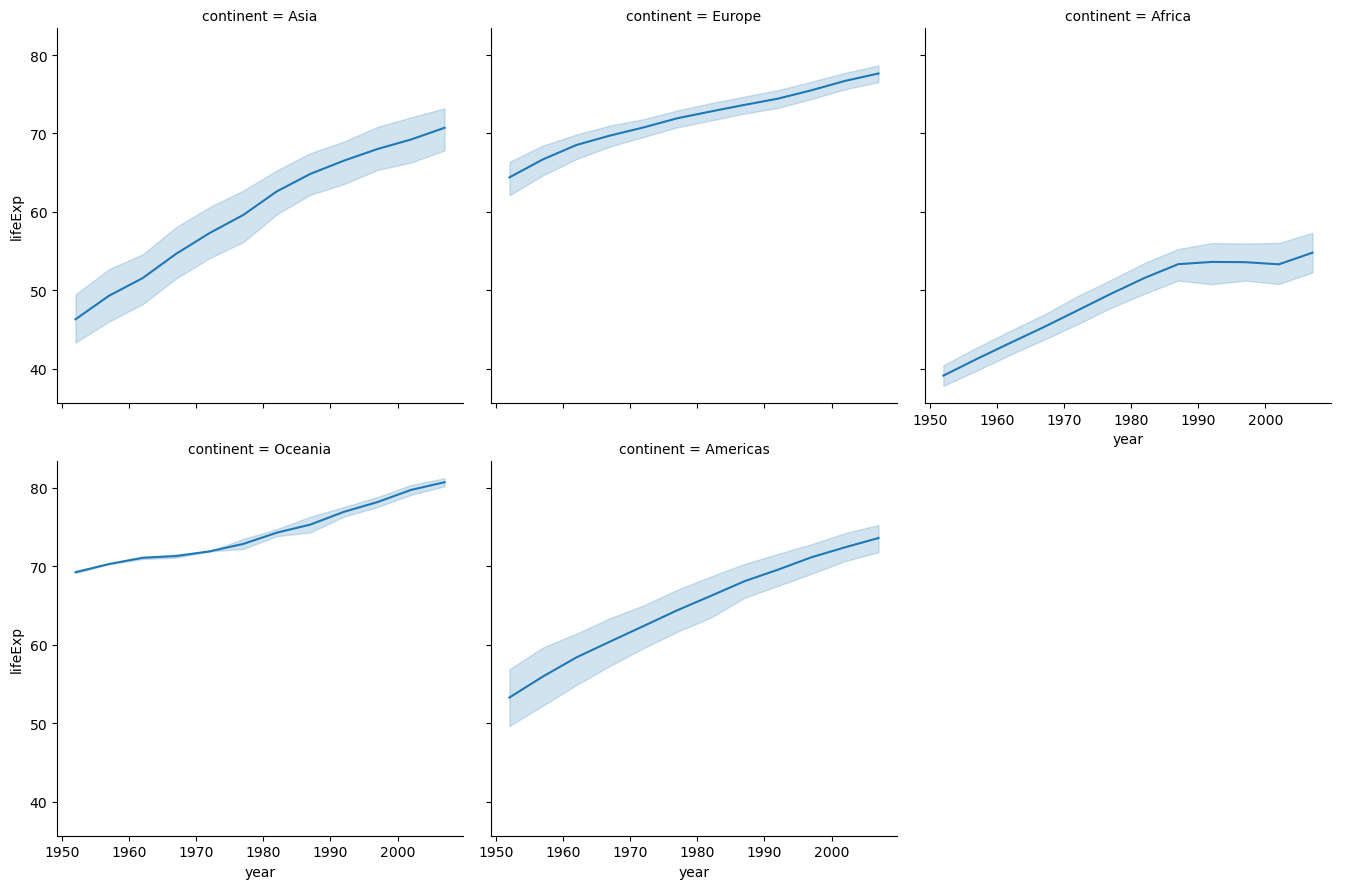

In [22]:
#change of life expectancy over time for different continents
a = sns.FacetGrid(data_all_continents,col = 'continent',col_wrap = 3,height = 4.5,aspect = 1)#height = 3,aspect = 0.8)
a.map(sns.lineplot,'year','lifeExp')
a.add_legend();

In the above example, datasets were appended (or stacked on top of each other).

Datasets can also be concatenated side-by-side (by providing the argument axis = 1 with the concat() function) as we saw with the merge function.

### Horizontal Concatenation (Combining Columns)

Setting `axis=1` combines DataFrames side-by-side by aligning their **indices**.

In [23]:
# Concatenate horizontally (axis=1) - combine columns
result = pd.concat([df_existing, df_external], axis=1)
result

,FellowshipID,FirstName,Skills,FellowshipID,FirstName,Age
0,1001.0,Frodo,Hiding,1001,Frodo,50
1,1002.0,Samwise,Gardening,1002,Samwise,39
2,1003.0,Gandalf,Spells,1006,Legolas,2931
3,1004.0,Pippin,Fireworks,1007,Elrond,6520
4,NaN,NaN,NaN,1008,Barromir,51


**Notice:**

- DataFrames are placed side-by-side
- **Index values are used for alignment** (matching FellowshipIDs are aligned)
- Non-matching indices result in NaN values
- This is similar to an outer join on the index

**When to use horizontal concat:**

- Adding new features/columns to existing data
- Combining results from different analyses on the same observations
- Building feature matrices for machine learning (each DataFrame contains different feature sets)

#### Handling Duplicate Column Names

When concatenating horizontally with duplicate column names, pandas keeps both columns:

In [24]:
# See column names when both DataFrames have 'Name'
result.columns

Index(['FellowshipID', 'FirstName', 'Skills', 'FellowshipID', 'FirstName',
       'Age'],
      dtype='object')

Both `Name` columns are kept, which can be confusing. You can use the `keys` parameter to create hierarchical column names:

In [25]:
# Use keys to label which DataFrame each column came from
result_labeled = pd.concat([df_existing, df_external], axis=1, keys=['Fellowship', 'Extended'])
result_labeled

Fellowship                          Extended                
  FellowshipID FirstName     Skills FellowshipID FirstName   Age
0       1001.0     Frodo     Hiding         1001     Frodo    50
1       1002.0   Samwise  Gardening         1002   Samwise    39
2       1003.0   Gandalf     Spells         1006   Legolas  2931
3       1004.0    Pippin  Fireworks         1007    Elrond  6520
4          NaN       NaN        NaN         1008  Barromir    51

Now you can clearly see which DataFrame each column came from. This creates a **MultiIndex** for columns (we'll cover this in detail in future chapters).

## Summary: Choosing the Right Method

Now that we've covered all three methods for combining DataFrames, here's how to choose:

| **Method** | **Best For** | **Key Feature** | **Common Pitfall** |
|-----------|-------------|-----------------|-------------------|
| `merge()` | Combining on **shared column(s)** | Flexible join types (inner/left/right/outer) | Forgetting to specify join type (defaults to inner) |
| `join()` | Combining on **index** values | Quick syntax for index-based joins | Index must be set up properly beforehand |
| `concat()` | Stacking DataFrames with **same structure** | Simple vertical/horizontal stacking | Doesn't match on keys (just stacks/aligns) |

### Decision Tree:

1. **Do you need to match rows based on values in columns?**
   
   - Yes → Use `merge()` (specify join type and `on=` parameter)
   
2. **Do you need to match rows based on index values?**
   
   - Yes → Use `join()` (ensure indices are meaningful)
   
3. **Do you just need to stack DataFrames?**
   
   - Vertically (add more rows) → Use `concat(axis=0)`
   - Horizontally (add more columns) → Use `concat(axis=1)` (aligns on index)

## Handling Missing Values After Combining Datasets

When you combine datasets using `merge()`, `join()`, or `concat()`, you often introduce **missing values (NaN)** for unmatched entries. Understanding *why* these appear and *how* to handle them is crucial for maintaining data quality.

### Why Missing Values Occur

Missing values appear for different reasons depending on the join type:

| Join Type | When NaN Appears | Example |
|-----------|------------------|---------|
| **Left Join** | Right DataFrame has no match for left keys | Customer exists but has no purchases → purchase columns = NaN |
| **Right Join** | Left DataFrame has no match for right keys | Purchase exists but customer deleted → customer columns = NaN |
| **Outer Join** | Either DataFrame has no match | Missing data from both sides |
| **concat (axis=1)** | Indices don't align | Different row indices → NaN where no alignment |

**Inner joins never produce NaN** from the join operation itself (only matched rows are kept).

### Strategies for Handling Missing Values

The right strategy depends on **why the data is missing** and **what you're analyzing**.

#### Strategy 1: Keep the Missing Values

**When to use:** Missing values are meaningful and represent "absence" of something.

**Example:** Customer purchase analysis with left join
```python
# All customers + their purchases (if any)
df_customer_purchases = customers.merge(purchases, on='CustomerID', how='left')
```

**Interpretation:**

- NaN in purchase columns = Customer hasn't made a purchase yet
- This is **informative** - these customers might be new or inactive
- Analysis: "What percentage of customers have never purchased?" requires keeping NaN

**Action:** Keep NaN and analyze it as a category (e.g., `df['Purchase'].isna().sum()`)

#### Strategy 2: Fill with Default Values

**When to use:** Missing values should be interpreted as zero or a default state.

**Example:** Sales data where no transaction = zero sales
```python
# Fill missing sales with 0
df_merged['TotalSales'] = df_merged['TotalSales'].fillna(0)
df_merged['TransactionCount'] = df_merged['TransactionCount'].fillna(0)
```

**Common fill values:**

- `0` - for counts, amounts, quantities
- `'None'` or `'Unknown'` - for categorical data
- `False` - for boolean flags
- Mean/median - for numerical features (use with caution!)

**Caution:** Only fill when you're certain what the missing value *means*.

#### Strategy 3: Drop Rows with Missing Values

**When to use:** Analysis requires complete information from both datasets.

**Example:** Analyzing relationship between two variables (need both)
```python
# Drop rows where either GDP or Population is missing
df_complete = df_merged.dropna(subset=['GDP', 'Population'])
```

**Options:**

- `dropna()` - drop rows with *any* NaN
- `dropna(subset=['col1', 'col2'])` - drop only if specific columns have NaN
- `dropna(thresh=5)` - drop only if fewer than 5 non-NaN values

**Caution:** You're losing data! Document how many rows were dropped and why.

#### Strategy 4: Use a Different Join Type

**When to use:** You're getting NaN because you used the wrong join type!

**Example:** Used outer join but only need matching rows
```python
# Wrong: Creates many NaN values
df_outer = pd.merge(df1, df2, how='outer')  # 1000 rows, 50% NaN

# Better: Use inner join to keep only complete matches
df_inner = pd.merge(df1, df2, how='inner')  # 600 rows, 0% NaN
```

**Before handling missing values, ask:**
1. Did I use the right join type for my analysis question?
2. Should I actually be using inner join instead of left/outer?
3. Are the missing values telling me about data quality issues?

### Practical Example: Handling Missing Values

Let's see these strategies in action with our fellowship data:

In [ ]:
# Create an outer join to see missing values
df_outer_example = pd.merge(df_existing, df_external, how='outer')

print("Outer join result:")
print(f"Total rows: {len(df_outer_example)}")
print(f"\nMissing values per column:")
print(df_outer_example.isnull().sum())
print(f"\nRows with ANY missing value: {df_outer_example.isnull().any(axis=1).sum()}")

df_outer_example

Now let's apply different strategies:

In [ ]:
# Strategy 1: Identify WHERE the missing values are
print("Rows with missing 'Race' (from left dataset):")
print(df_outer_example[df_outer_example['Race'].isna()][['Name', 'Race', 'Birthplace']])
print()

print("Rows with missing 'Birthplace' (from right dataset):")
print(df_outer_example[df_outer_example['Birthplace'].isna()][['Name', 'Race', 'Birthplace']])

In [ ]:
# Strategy 2: Drop incomplete rows (for complete-case analysis)
df_complete = df_outer_example.dropna()

print(f"Original rows: {len(df_outer_example)}")
print(f"Complete rows: {len(df_complete)}")
print(f"Rows dropped: {len(df_outer_example) - len(df_complete)}")
print()
df_complete

In [ ]:
# Strategy 3: Fill with meaningful defaults
df_filled = df_outer_example.copy()
df_filled['Birthplace'] = df_filled['Birthplace'].fillna('Unknown')

print("After filling missing 'Birthplace' with 'Unknown':")
print(df_filled[['Name', 'Birthplace']])
print(f"\nMissing 'Birthplace' values: {df_filled['Birthplace'].isna().sum()}")

### Best Practices for Missing Value Handling

**1. Investigate First**
```python
# Always check WHERE and WHY values are missing
df.isnull().sum()  # Count per column
df[df['column'].isna()]  # See the actual rows
```

**2. Document Your Decisions**
```python
# Good: Document what you did and why
# Filled missing GDP with 0 because these are countries with no economic data reported
df['GDP'] = df['GDP'].fillna(0)

# Also good: Create a flag for missing values before filling
df['GDP_was_missing'] = df['GDP'].isna()
df['GDP'] = df['GDP'].fillna(df['GDP'].median())
```

**3. Consider the Impact**

- **Dropping rows:** Reduces sample size, may introduce bias
- **Filling with defaults:** May distort statistics (mean, correlations)
- **Keeping NaN:** Requires careful handling in analysis/visualization

**4. Choose Join Type Carefully**

The best way to handle missing values is often to **prevent them** by using the right join type for your analysis question!



**Remember:** Missing values after combining datasets are **expected and normal**. The key is understanding what they mean and handling them appropriately for your specific analysis goals.

## Independent Study 

###  Merging GDP per capita and population datasets

In this independent study on **data reshaping**, we have provided two datasets:  
- `gdp_per_capita_data`  
- `population_data`  

This exercise builds on the results from the previous section.

**Task:**  
Merge `gdp_per_capita_data` with `population_data` to combine each country's **population** and **GDP per capita** into a single DataFrame.  
Finally, print the **first two rows** of the merged DataFrame.

Assume that:

1. We want to keep the GDP per capita of all countries in the merged dataset, even if their population in unavailable in the population dataset. For countries whose population in unavailable, their `Population` column will show `NA`.

2. We want to discard an observation of a country if its GDP per capita is unavailable.



####  
For how many countries in `gdp_per_capita_data` does the population seem to be unavailable in `population_data`? Note that you don't need to clean country names any further than cleaned by the functions provided.

Print the observations of `gdp_per_capita_data` with missing `Population`.



### Merging datasets with *similar* values in the *key* column

We suspect that population of more countries may be available in `population_data`. However, due to unclean country names, the observations could not merge. For example, the country *Guinea Bissau* is mentioned as *GuineaBissau* in `gdp_per_capita_data` and *Guinea-Bissau* in `population_data`. To resolve this issue, we'll use a different approach to merge datasts. We'll merge the population of a country to an observation in the GDP per capita dataset, whose name in `population_data` is the most *'similar'* to the name of the country in `gdp_per_capita_data`. 

#### 
Proceed as follows:

1. For each country in `gdp_per_capita_data`, find the `country` with the most *'similar'* name in `population_data`, based on the similarity score. Use the lambda function provided below to compute the similarity score between two strings *(The higher the score, the more similar are the strings. The similarity score is $1.0$ if two strings are exactly the same).*


2. Merge the population of the most *'similar'* country to the country in `gdp_per_capita_data`. The merged dataset must include 5 columns - the country name as it appears in `gdp_per_capita_data`, the GDP per capita, the country name of the most *'similar'* country as it appears in `population_data`, the population of that country, and the similarity score between the country names. 


3. After creating the merged dataset, **print** the rows of the dataset that have similarity scores less than 1.

Use the function below to compute the similarity score between the `Country` names of the two datasets:

`from difflib import SequenceMatcher`

`similar = lambda a,b: SequenceMatcher(None, a, b).ratio()`

**Note: You may use one `for` loop only for this particular question. However, it would be perfect if don't use a `for` loop**



**Hint:**

1. Define a function that computes the index of the observation having the most *'similar'* country name in `population_data` for an observation in `gdp_per_capita_data`. The function returns a Series consisting of the most *'similar'* country name, its population, and its similarity score *(This function can be written with only one line in its body, excluding the return statement and the definition statement. However, you may use as many lines as you wish)*.


2. Apply the function on the `Country` column of `gdp_per_capita_data`. A DataFrame will be obtained.


3. Concatenate the DataFrame obtained in (2) with `gdp_per_capita_data` with the pandas `concat()` function.

####
In the dataset obtained in the previous question, for all observations where similarity score is less than 0.8, replace the population with Nan.

Print the observations of the dataset having missing values of population.